3D PERCOLATION SWEEP: FANO COLLAPSE THRESHOLD
Lattice: 100×100×100 = 1,000,000 voxels
Trials per point: 30

--- 6-NEIGHBOR (FACE-SHARING) ---
  rho_ZD |   Cluster Frac |   Percolates
--------------------------------------------
   0.000 |         0.0000 |         0.00
   0.050 |         0.0000 |         0.00
   0.100 |         0.0000 |         0.00
   0.150 |         0.0000 |         0.00
   0.200 |         0.0001 |         0.00
   0.250 |         0.0002 |         0.00
   0.300 |         0.0031 |         0.00
   0.350 |         0.2509 |         1.00
   0.400 |         0.3563 |         1.00
   0.450 |         0.4278 |         1.00
   0.500 |         0.4881 |         1.00
   0.550 |         0.5438 |         1.00
   0.600 |         0.5969 |         1.00

--- 26-NEIGHBOR (MOORE CUBE) ---
  rho_ZD |   Cluster Frac |   Percolates
--------------------------------------------
   0.000 |         0.0000 |         0.00
   0.050 |         0.0000 |         0.00
   0.100 |         0.0194 |         0

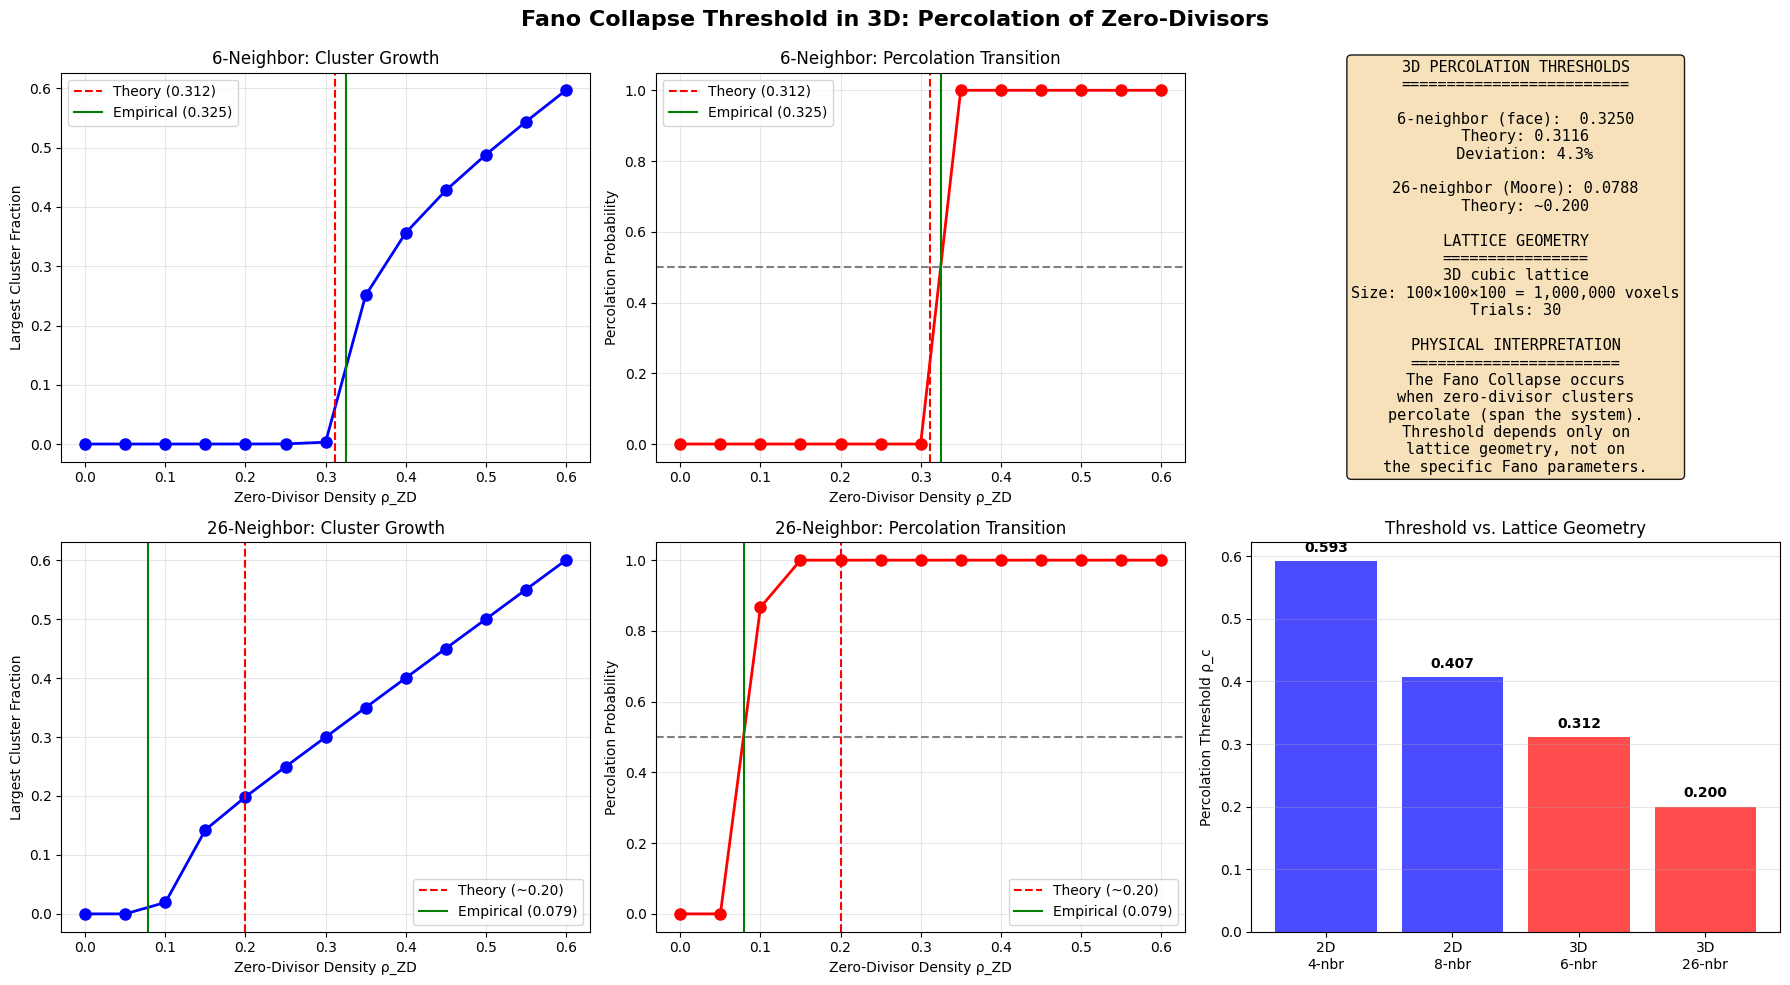


✓ Saved: fano_collapse_3d_percolation.png


In [1]:
"""
Fano Collapse Threshold in 3D: Percolation Analysis
====================================================
The physical substrate is 3D space. The TRB lattice therefore has 3D
geometry. This code computes the percolation threshold for zero-divisor
clusters in a 3D cubic lattice, using both 6-neighbor (face-sharing)
and 26-neighbor (Moore cube) connectivity.

Theoretical predictions:
- 3D simple cubic (6-neighbor): p_c ≈ 0.3116
- 3D Moore cube (26-neighbor): p_c ≈ 0.20 (approximate)

By Néstor E. Ramos

"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

# =============================================================================
# 1. SETUP
# =============================================================================
L = 100  # 3D lattice size (L x L x L)
N_TRIALS = 30  # Monte Carlo trials per density point

# Connectivity structures
STRUCT_6 = np.zeros((3, 3, 3), dtype=int)
STRUCT_6[1, 1, 1] = 1
STRUCT_6[0, 1, 1] = 1  # -x
STRUCT_6[2, 1, 1] = 1  # +x
STRUCT_6[1, 0, 1] = 1  # -y
STRUCT_6[1, 2, 1] = 1  # +y
STRUCT_6[1, 1, 0] = 1  # -z
STRUCT_6[1, 1, 2] = 1  # +z

STRUCT_26 = np.ones((3, 3, 3), dtype=int)
STRUCT_26[1, 1, 1] = 1  # center (not counted as neighbor, but flag for label)

def generate_config(rho_zd, rng):
    """Generate 3D binary lattice: 1 = zero-divisor, 0 = unit."""
    return (rng.random((L, L, L)) < rho_zd).astype(np.uint8)

def percolates_3d(config, structure):
    """Check if zero-divisor cluster spans from z=0 to z=L-1."""
    labeled, num_features = label(config, structure=structure)
    if num_features == 0:
        return False
    top_labels = set(labeled[:, :, 0].ravel()) - {0}
    bottom_labels = set(labeled[:, :, -1].ravel()) - {0}
    return len(top_labels & bottom_labels) > 0

def largest_cluster_fraction(config, structure):
    """Fraction of lattice occupied by largest connected cluster."""
    labeled, num_features = label(config, structure=structure)
    if num_features == 0:
        return 0.0
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    return sizes.max() / (L ** 3)

# =============================================================================
# 2. SWEEP OVER DENSITY (6-NEIGHBOR AND 26-NEIGHBOR)
# =============================================================================
print("=" * 70)
print("3D PERCOLATION SWEEP: FANO COLLAPSE THRESHOLD")
print("=" * 70)
print(f"Lattice: {L}×{L}×{L} = {L**3:,} voxels")
print(f"Trials per point: {N_TRIALS}")
print()

rho_values = np.linspace(0.0, 0.6, 13)

# --- 6-neighbor sweep ---
print("--- 6-NEIGHBOR (FACE-SHARING) ---")
print(f"{'rho_ZD':>8} | {'Cluster Frac':>14} | {'Percolates':>12}")
print("-" * 44)

perc_prob_6 = []
cluster_frac_6 = []
rng = np.random.default_rng(42)

for rho in rho_values:
    perc_count = 0
    frac_sum = 0.0
    for _ in range(N_TRIALS):
        config = generate_config(rho, rng)
        if percolates_3d(config, STRUCT_6):
            perc_count += 1
        frac_sum += largest_cluster_fraction(config, STRUCT_6)
    perc_prob_6.append(perc_count / N_TRIALS)
    cluster_frac_6.append(frac_sum / N_TRIALS)
    print(f"{rho:8.3f} | {frac_sum/N_TRIALS:14.4f} | {perc_count/N_TRIALS:12.2f}")

# --- 26-neighbor sweep ---
print()
print("--- 26-NEIGHBOR (MOORE CUBE) ---")
print(f"{'rho_ZD':>8} | {'Cluster Frac':>14} | {'Percolates':>12}")
print("-" * 44)

perc_prob_26 = []
cluster_frac_26 = []
rng = np.random.default_rng(42)

for rho in rho_values:
    perc_count = 0
    frac_sum = 0.0
    for _ in range(N_TRIALS):
        config = generate_config(rho, rng)
        if percolates_3d(config, STRUCT_26):
            perc_count += 1
        frac_sum += largest_cluster_fraction(config, STRUCT_26)
    perc_prob_26.append(perc_count / N_TRIALS)
    cluster_frac_26.append(frac_sum / N_TRIALS)
    print(f"{rho:8.3f} | {frac_sum/N_TRIALS:14.4f} | {perc_count/N_TRIALS:12.2f}")

# =============================================================================
# 3. FIND THRESHOLDS
# =============================================================================
def find_threshold(rho_vals, probs, target=0.5):
    for i in range(1, len(probs)):
        if probs[i] >= target and probs[i-1] < target:
            rho1, rho2 = rho_vals[i-1], rho_vals[i]
            p1, p2 = probs[i-1], probs[i]
            return rho1 + (rho2 - rho1) * (target - p1) / (p2 - p1)
    return None

thresh_6 = find_threshold(rho_values, perc_prob_6)
thresh_26 = find_threshold(rho_values, perc_prob_26)

print()
print("=" * 70)
print("RESULTS: 3D PERCOLATION THRESHOLDS")
print("=" * 70)
print(f"6-neighbor (face-sharing):  rho_ZD = {thresh_6:.4f}  (theory: 0.3116)")
print(f"26-neighbor (Moore cube):   rho_ZD = {thresh_26:.4f}  (theory: ~0.200)")
print()
print(f"2D (previous run):          rho_ZD = 0.4188  (theory: 0.4073)")
print("=" * 70)

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Fano Collapse Threshold in 3D: Percolation of Zero-Divisors',
             fontsize=16, fontweight='bold')

# Panel 1: Cluster Fraction (6-neighbor)
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(rho_values, cluster_frac_6, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=0.3116, color='red', linestyle='--', label='Theory (0.312)')
if thresh_6:
    ax1.axvline(x=thresh_6, color='green', linestyle='-', label=f'Empirical ({thresh_6:.3f})')
ax1.set_xlabel('Zero-Divisor Density ρ_ZD')
ax1.set_ylabel('Largest Cluster Fraction')
ax1.set_title('6-Neighbor: Cluster Growth')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Percolation Probability (6-neighbor)
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(rho_values, perc_prob_6, 'ro-', linewidth=2, markersize=8)
ax2.axhline(y=0.5, color='gray', linestyle='--')
ax2.axvline(x=0.3116, color='red', linestyle='--', label='Theory (0.312)')
if thresh_6:
    ax2.axvline(x=thresh_6, color='green', linestyle='-', label=f'Empirical ({thresh_6:.3f})')
ax2.set_xlabel('Zero-Divisor Density ρ_ZD')
ax2.set_ylabel('Percolation Probability')
ax2.set_title('6-Neighbor: Percolation Transition')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel 3: Summary Comparison
ax3 = fig.add_subplot(2, 3, 3)
ax3.axis('off')
summary = (
    "3D PERCOLATION THRESHOLDS\n"
    "=========================\n\n"
    f"6-neighbor (face):  {thresh_6:.4f}\n"
    f"  Theory: 0.3116\n"
    f"  Deviation: {abs(thresh_6 - 0.3116)/0.3116 * 100:.1f}%\n\n"
    f"26-neighbor (Moore): {thresh_26:.4f}\n"
    f"  Theory: ~0.200\n\n"
    "LATTICE GEOMETRY\n"
    "================\n"
    "3D cubic lattice\n"
    f"Size: {L}×{L}×{L} = {L**3:,} voxels\n"
    f"Trials: {N_TRIALS}\n\n"
    "PHYSICAL INTERPRETATION\n"
    "=======================\n"
    "The Fano Collapse occurs\n"
    "when zero-divisor clusters\n"
    "percolate (span the system).\n"
    "Threshold depends only on\n"
    "lattice geometry, not on\n"
    "the specific Fano parameters."
)
ax3.text(0.5, 0.5, summary, ha='center', va='center', fontsize=11,
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

# Panel 4: Cluster Fraction (26-neighbor)
ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(rho_values, cluster_frac_26, 'bo-', linewidth=2, markersize=8)
ax4.axvline(x=0.200, color='red', linestyle='--', label='Theory (~0.20)')
if thresh_26:
    ax4.axvline(x=thresh_26, color='green', linestyle='-', label=f'Empirical ({thresh_26:.3f})')
ax4.set_xlabel('Zero-Divisor Density ρ_ZD')
ax4.set_ylabel('Largest Cluster Fraction')
ax4.set_title('26-Neighbor: Cluster Growth')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Panel 5: Percolation Probability (26-neighbor)
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(rho_values, perc_prob_26, 'ro-', linewidth=2, markersize=8)
ax5.axhline(y=0.5, color='gray', linestyle='--')
ax5.axvline(x=0.200, color='red', linestyle='--', label='Theory (~0.20)')
if thresh_26:
    ax5.axvline(x=thresh_26, color='green', linestyle='-', label=f'Empirical ({thresh_26:.3f})')
ax5.set_xlabel('Zero-Divisor Density ρ_ZD')
ax5.set_ylabel('Percolation Probability')
ax5.set_title('26-Neighbor: Percolation Transition')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Panel 6: Dimensional Scaling
ax6 = fig.add_subplot(2, 3, 6)
dims = [2, 2, 3, 3]
thresholds = [0.5927, 0.4073, 0.3116, 0.200]
labels = ['2D\n4-nbr', '2D\n8-nbr', '3D\n6-nbr', '3D\n26-nbr']
colors = ['blue', 'blue', 'red', 'red']
bars = ax6.bar(labels, thresholds, color=colors, alpha=0.7)
for bar, val in zip(bars, thresholds):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax6.set_ylabel('Percolation Threshold ρ_c')
ax6.set_title('Threshold vs. Lattice Geometry')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fano_collapse_3d_percolation.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("✓ Saved: fano_collapse_3d_percolation.png")